# 06 Molecular Orbitals

In [1]:
%load_ext autoreload
%autoreload 2

import sys

import numpy as np
import pandas as pd

from config import DATA_DIR, PROJECT_ROOT, PROCESSED_DATAFRAMES_DIR, RAW_MATRICES_DIR
from notebook_utils.general import parse_active_space, read_npz, save_figure
from notebook_utils.graphs import plot_low_state_double_weight_scaling, show_scrollable_figs
from notebook_utils.operators import get_dominant_exact_transitions, get_excitation_percentages

sys.path.append(str(PROJECT_ROOT / "scripts"))
from script_utils import MOLECULE_NAMES, load_pyscf_mol


CASCI_DIR = RAW_MATRICES_DIR / "pyscf_casci"
MOLECULE_INFO_PATH = PROCESSED_DATAFRAMES_DIR / "Orbital_Character.csv"
VISUALISE_DIR = DATA_DIR / "visualise"

In [2]:
def load_casci_records(path):
    records = []

    for file in sorted(path.rglob("*.npz")):
        row = read_npz(file)
        records.append({
            "molecule": row["molecule"],
            "active_space": row["active_space"],
            "spin_type": row["spin_type"],
            "casci_energies": row["casci_energies"],
            "casci_pvec": row["casci_pvec"],
            "sectors": row["sectors"],
        })

    return pd.DataFrame(records)

In [3]:
df_molecule_info = pd.read_csv(MOLECULE_INFO_PATH)
df_casci = load_casci_records(CASCI_DIR)

assert not df_casci.duplicated(["molecule", "active_space", "spin_type"]).any()
assert set(df_molecule_info["Molecule"]) == set(MOLECULE_NAMES)
assert set(df_casci["molecule"]) == set(MOLECULE_NAMES)

print(f"Molecule information: {len(df_molecule_info):,} rows")
print(f"Exact CASCI data: {len(df_casci):,} rows")
display(df_molecule_info.head(), df_casci.head())

Molecule information: 28 rows
Exact CASCI data: 560 rows


,Class,Molecule,Point Group,S1_Orb,T1_Orb,T2_Orb,S1_Irrep,T1_Irrep,T2_Irrep
0,Unsaturated Aliphatic Hydrocarbons,Ethene,D2h,pi->pi*,pi->pi*,-,B1u,B1u,-
1,Unsaturated Aliphatic Hydrocarbons,Butadiene,C2h,pi->pi*,pi->pi*,pi->pi*,Bu,Bu,Ag
2,Unsaturated Aliphatic Hydrocarbons,Hexatriene,C2h,pi->pi*,pi->pi*,pi->pi*,Bu,Bu,Ag
3,Unsaturated Aliphatic Hydrocarbons,Octatetraene,C2h,pi->pi*,pi->pi*,pi->pi*,Ag,Bu,Ag
4,Unsaturated Aliphatic Hydrocarbons,Cyclopentadiene,C2v,pi->pi*,pi->pi*,pi->pi*,B2,B2,A1


,molecule,active_space,spin_type,casci_energies,casci_pvec,sectors
0,Acetamide,2e2o,singlet,"[-205.2944990546729, -204.82581813267245, -204...","[[-0.15005468780119358, 0.0, -0.00628467531206...",[0]
1,Acetone,2e2o,singlet,"[-189.53490561664324, -189.34994608084307, -18...","[[-0.03488837830845926, 0.0, -1.41916213449700...",[0]
2,Adenine,2e2o,singlet,"[-458.62283529025024, -458.30436202077107, -45...","[[-0.10926579142841673, 0.0, -0.00117100649782...",[0]
3,Benzene,2e2o,singlet,"[-227.90595286483972, -227.50132277673768, -22...","[[-0.15753317906877212, 0.0, 4.517188078495829...",[0]
4,Benzoquinone,2e2o,singlet,"[-374.36425429885287, -374.0360707174654, -373...","[[-0.18592169564989755, 0.0, 1.534333636669296...",[0]


## Exact CASCI Transition Composition

In [7]:
TRANSITION_CSV_PATH = PROCESSED_DATAFRAMES_DIR / "exact_casci_dominant_transitions.csv"


def get_hf_state(active_space):
    num_electrons, num_orbitals = parse_active_space(active_space)
    num_occupied = num_electrons // 2
    return "11" * num_occupied + "00" * (num_orbitals - num_occupied)


def format_dominant_transitions(pvecs, hf_state):
    transitions = get_dominant_exact_transitions(pvecs, hf_state)
    terms = [
        f"HF ({weight:.2f}%)" if category == "HF" else f"{category} {label} ({weight:.2f}%)"
        for category, label, weight in transitions
    ]
    return "\n".join(terms) + f" [{sum(weight for _, _, weight in transitions):.2f}%]"


active_spaces = sorted(df_casci["active_space"].unique(), key=parse_active_space)
singlet_rows = df_casci[df_casci["spin_type"] == "singlet"].set_index(["molecule", "active_space"])
triplet_rows = df_casci[df_casci["spin_type"] == "triplet"].set_index(["molecule", "active_space"])

transition_rows = []
for molecule in MOLECULE_NAMES:
    for active_space in active_spaces:
        hf_state = get_hf_state(active_space)
        singlet_pvecs = singlet_rows.loc[molecule, active_space]["casci_pvec"]
        triplet_pvecs = triplet_rows.loc[molecule, active_space]["casci_pvec"]

        s0 = format_dominant_transitions(singlet_pvecs[0], hf_state)
        s1 = format_dominant_transitions(singlet_pvecs[1], hf_state)
        t1 = format_dominant_transitions(triplet_pvecs[0], hf_state)
        t2 = "Unavailable" if len(triplet_pvecs) < 2 else format_dominant_transitions(triplet_pvecs[1], hf_state)
        transition_rows.append({
            "molecule": molecule,
            "active_space": active_space,
            "s0": s0,
            "s1": s1,
            "t1": t1,
            "t2": t2,
        })

df_exact_casci_dominant_transitions = pd.DataFrame(transition_rows)


df_exact_casci_dominant_transitions.to_csv(TRANSITION_CSV_PATH, index=False)

sample_keys = pd.MultiIndex.from_tuples([
    ("Acetamide", "6e6o"),
    ("Butadiene", "4e4o"),
    ("Benzene", "6e6o"),
])
sample = df_exact_casci_dominant_transitions.set_index(["molecule", "active_space"]).loc[sample_keys]
with pd.option_context("display.max_colwidth", None):
    display(sample)
print(f"Saved {TRANSITION_CSV_PATH}")

,,s0,s1,t1,t2
molecule,active_space,,,,
Acetamide,6e6o,"HF (95.43%)\nPaired double 3,3 -> 4,4 (2.45%)\nMixed double 1,3 -> 4,4 (1.07%)\nPaired double 1,1 -> 4,4 (0.39%) [99.33%]","Single 2 -> 4 (92.42%)\nMixed double 2,3 -> 4,4 (5.05%)\nMixed double 1,2 -> 4,4 (2.28%) [99.75%]","Single 2 -> 4 (94.89%)\nMixed double 2,3 -> 4,4 (3.24%)\nMixed double 1,2 -> 4,4 (1.59%) [99.71%]",Single 3 -> 4 (90.43%)\nSingle 1 -> 4 (9.16%) [99.59%]
Butadiene,4e4o,"HF (87.37%)\nMixed double 1,2 -> 3,4 (5.24%)\nPaired double 2,2 -> 3,3 (4.62%)\nPaired double 1,1 -> 4,4 (0.90%)\nPaired double 1,1 -> 3,3 (0.82%)\nPaired double 2,2 -> 4,4 (0.70%) [99.64%]","Paired double 2,2 -> 3,3 (31.11%)\nSingle 1 -> 3 (19.13%)\nSingle 2 -> 4 (14.19%)\nPaired double 1,1 -> 3,3 (11.79%)\nMixed double 1,2 -> 3,4 (10.91%)\nPaired double 2,2 -> 4,4 (9.15%)\nPaired double 1,1 -> 4,4 (2.69%)\nHF (0.51%) [99.49%]","Single 2 -> 3 (80.42%)\nSingle 1 -> 4 (11.62%)\nHigher 1,2,2 -> 3,3,4 (2.49%)\nMixed double 1,2 -> 3,3 (1.77%)\nHigher 1,1,2 -> 3,4,4 (1.64%)\nMixed double 2,2 -> 3,4 (1.55%) [99.49%]","Single 1 -> 3 (51.32%)\nSingle 2 -> 4 (40.86%)\nHigher 1,1,2 -> 3,3,4 (2.70%)\nHigher 1,2,2 -> 3,4,4 (2.58%)\nMixed double 1,2 -> 3,4 (2.54%) [100.00%]"
Benzene,6e6o,"HF (92.11%)\nMixed double 2,3 -> 4,5 (2.80%)\nPaired double 2,2 -> 5,5 (2.17%)\nPaired double 3,3 -> 4,4 (2.17%) [99.26%]","Single 3 -> 5 (44.70%)\nSingle 2 -> 4 (44.69%)\nMixed double 2,3 -> 5,6 (4.54%)\nMixed double 3,3 -> 4,6 (2.27%)\nMixed double 2,2 -> 4,6 (2.27%)\nHigher 2,2,3 -> 5,6,6 (0.64%) [99.11%]","Single 2 -> 5 (47.20%)\nSingle 3 -> 4 (47.16%)\nHigher 2,3,3 -> 4,4,5 (1.60%)\nHigher 2,2,3 -> 4,5,5 (1.60%)\nMixed double 2,3 -> 4,6 (1.11%)\nMixed double 2,2 -> 5,6 (0.55%) [99.21%]","Single 3 -> 5 (46.31%)\nSingle 2 -> 4 (46.30%)\nMixed double 2,3 -> 5,6 (4.97%)\nMixed double 3,3 -> 4,6 (1.36%)\nHigher 2,2,3 -> 5,6,6 (0.25%) [99.18%]"


Saved /Users/naythanyeo/Documents/Research/2026/Quantum Chemistry/qse-practical-analysis/data/processed_dataframes/exact_casci_dominant_transitions.csv


## Exact CASCI Double-Excitation Weights


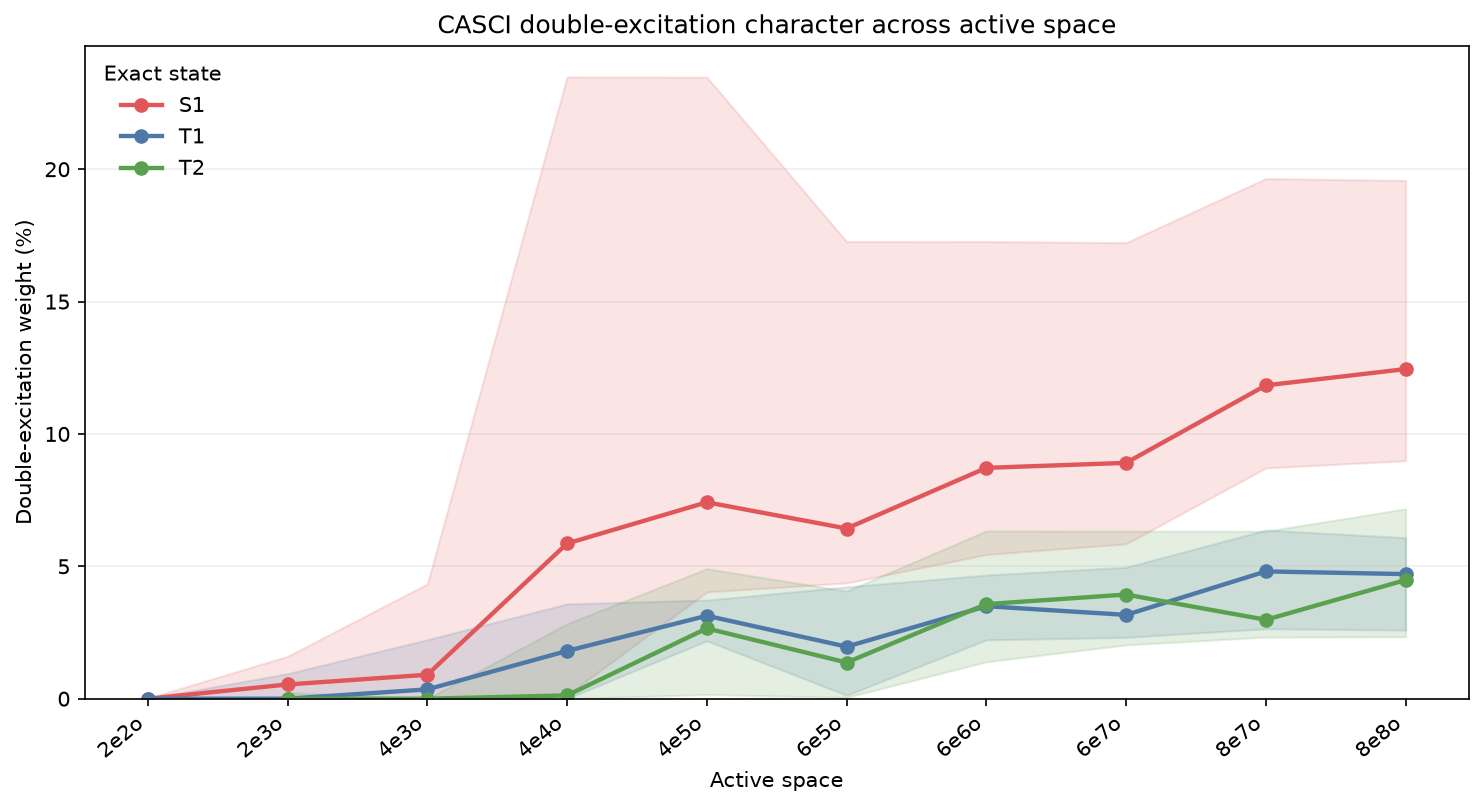

In [4]:
def get_low_state_double_weights(df_casci):
    state_roots = {"singlet": {"s1": 1}, "triplet": {"t1": 0, "t2": 1}}
    records = []

    for _, row in df_casci.iterrows():
        num_electrons, num_orbitals = parse_active_space(row["active_space"])
        hf_state = "11" * (num_electrons // 2) + "00" * (num_orbitals - num_electrons // 2)

        for state, root in state_roots[row["spin_type"]].items():
            if root >= len(row["casci_pvec"]):
                continue

            sector_weights = [
                get_excitation_percentages(pvec, hf_state)[2]
                for pvec in np.atleast_2d(row["casci_pvec"][root])
            ]
            records.append({
                "molecule": row["molecule"],
                "active_space": row["active_space"],
                "state": state,
                "doubles": float(np.mean(sector_weights)),
            })

    return pd.DataFrame(records)


df_low_state_double_weights = get_low_state_double_weights(df_casci)
active_spaces = sorted(df_low_state_double_weights["active_space"].unique(), key=parse_active_space)
states = ["s1", "t1", "t2"]
double_weight_data = {
    active_space: {
        state: df_low_state_double_weights.loc[
            (df_low_state_double_weights["active_space"] == active_space)
            & (df_low_state_double_weights["state"] == state), "doubles"
        ].to_numpy()
        for state in states
    }
    for active_space in active_spaces
}

low_state_double_weight_figure = plot_low_state_double_weight_scaling(double_weight_data)
save_figure(
    low_state_double_weight_figure, "casci_doubles_weight", "low_state_double_excitation_weight_scaling"
)
show_scrollable_figs([low_state_double_weight_figure])
